# SmartCart Day 2 - Localize

Day 1 gave us labelled single-product photos. A checkout sees a **counter full of items**, but GroceryStoreDataset does **not** provide bounding boxes. Today we create box labels by compositing real product photos into multi-item scenes, fine-tune **YOLO11** to find products, and crop the detections back out for Day 3's recognizer.

In [1]:
# 1) Runtime setup
# Install only the packages used in this notebook.
%pip install -q ultralytics

import os

# The cross-day bundle lives in a local folder (was a Google Drive mount on Colab).
# Day 1 (day_1/Day1_acquire_index.ipynb) writes to this same path for continuity.
BUNDLE_DIR = os.path.expanduser('~/SmartCart_bundle')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Embedded toolkit

This hidden cell defines the helper functions used below. It is embedded so the notebook needs no separate `.py` upload. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir
GROCERY_DATASET_URL = 'https://github.com/marcusklasson/GroceryStoreDataset'

class Bundle:
    """Small local folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir=None) -> Bundle:
    """Open the cross-day local bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir or os.path.expanduser('~/SmartCart_bundle')).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def open_grocery_dataset():
    """Clone or reuse the real GroceryStoreDataset and return (tier, root_dir)."""
    root = HERE / 'GroceryStoreDataset'
    if (root / 'dataset' / 'classes.csv').exists():
        print('using cached GroceryStoreDataset:', root)
    else:
        print('cloning GroceryStoreDataset from:', GROCERY_DATASET_URL)
        subprocess.run(['git', 'clone', '--depth', '1', GROCERY_DATASET_URL, str(root)], check=True)
    if not (root / 'dataset' / 'classes.csv').exists():
        raise RuntimeError('GroceryStoreDataset clone is incomplete. Check network access and rerun.')
    print('using data tier: github')
    print('data root:', root)
    print('OK: using real GroceryStoreDataset images.')
    return ('github', str(root))

def open_sg_dataset(sg_root=None):
    """SG innovation swap for open_grocery_dataset(): point at our own Singapore
    catalog (sg_data/) instead of the course-default GroceryStoreDataset. Returns
    the same (tier, root_dir) shape so downstream code doesn't need to branch."""
    root = pathlib.Path(sg_root or (HERE.parent / 'sg_data'))
    if not (root / 'labels.csv').exists():
        raise RuntimeError(f'sg_data not found at {root} (expected labels.csv). '
                            f'Check the path or run Week4/sg_data/collect_sg_groceries.py first.')
    print('using data tier: sg_data (Singapore catalog)')
    print('data root:', root)
    print('OK: using real FairPrice-sourced Singapore product images.')
    return ('sg_data', str(root))

def list_images(root, per_class=None):
    """Return a DataFrame with columns path,coarse,fine.
    Handles two layouts: GroceryStoreDataset's train/val/test split folders, and
    sg_data's flat labels.csv (path,coarse,fine) — detected by which one exists."""
    root = pathlib.Path(root)
    labels_csv = root / 'labels.csv'
    if labels_csv.exists():
        df = pd.read_csv(labels_csv)
        df['path'] = df['path'].map(lambda p: p if pathlib.Path(p).is_absolute() else str((root / p).resolve()))
    else:
        rows = []
        for split in ('train', 'val', 'test'):
            for p in (root / 'dataset' / split).rglob('*.jpg'):
                rows.append({'path': str(p), 'coarse': p.parent.parent.name, 'fine': p.parent.name})
        df = pd.DataFrame(rows)
    if per_class and len(df):
        df = df.groupby('fine', group_keys=False).head(per_class).reset_index(drop=True)
    return df

def compose_scene(crops, canvas=(640, 640), seed=0, max_items=None):
    """Paste crops onto a blank canvas. Paste coordinates become detection boxes."""
    rng = np.random.default_rng(seed)
    H, W = canvas
    tint = rng.integers(225, 250, size=(1, 1, 3), dtype=np.uint8)
    noise = rng.integers(0, 12, size=(H, W, 3), dtype=np.uint8)
    img = np.minimum(tint + noise, 255).astype(np.uint8)
    boxes = []

    def iou_xywh(a, b):
        ax, ay, aw, ah = a
        bx, by, bw, bh = b
        ix1, iy1 = (max(ax, bx), max(ay, by))
        ix2, iy2 = (min(ax + aw, bx + bw), min(ay + ah, by + bh))
        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        union = aw * ah + bw * bh - inter
        return inter / union if union else 0.0
    for crop, label in crops if max_items is None else crops[:max_items]:
        ch, cw = crop.shape[:2]
        if ch >= H or cw >= W:
            continue
        x, y = (0, 0)
        for _ in range(40):
            x = int(rng.integers(0, W - cw))
            y = int(rng.integers(0, H - ch))
            if all((iou_xywh((x, y, cw, ch), b[:4]) < 0.08 for b in boxes)):
                break
        img[y:y + ch, x:x + cw] = crop
        boxes.append((x, y, cw, ch, label))
    return (img, boxes)

def yolo_boxes_to_txt(boxes, canvas, class_to_id):
    """Convert (x,y,w,h,label) pixel boxes to YOLO txt lines."""
    H, W = canvas
    lines = []
    for x, y, w, h, label in boxes:
        lines.append(f'{class_to_id[label]} {(x + w / 2) / W:.6f} {(y + h / 2) / H:.6f} {w / W:.6f} {h / H:.6f}')
    return '\n'.join(lines)
# --- helpers are now available as plain functions/classes in this notebook ---
print('SmartCart toolkit ready')

SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
# The bundle stores artifacts we create during the week: labels, indexes, weights, ONNX files.
# It is NOT the image dataset. Images are loaded in the next data-source cell.
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: /home/jonyling/SmartCart_bundle
artifacts: ['sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md', 'head_v2.pt', 'lift_table.csv', 'lift_table_vs_real_photo.csv', 'decisive_lift_table.csv', 'confidence_threshold.json', 'head.onnx']


In [4]:
# 3) Select the image data source
# SG innovation swap (D1): use our own Singapore catalog instead of the course
# default. Both return the same (tier, root) shape, so nothing downstream changes —
# detection here is class-agnostic (every SKU -> one 'product' id), so the only
# effect is that composed scenes now contain Singapore products.
USE_SG_CATALOG = True
if USE_SG_CATALOG:
    tier, root = open_sg_dataset()
else:
    tier, root = open_grocery_dataset()


using data tier: sg_data (Singapore catalog)
data root: /home/jonyling/SNAIC/Week4/sg_data
OK: using real FairPrice-sourced Singapore product images.


## List product images (this runtime)

**What:** Re-list the product images from the data tier - paths must be valid in *today's* runtime.

**Why:** The dataset is re-cloned per run rather than trusting absolute paths saved on another day or machine.

**Watch for:** Confirm the previous cell printed `using data tier: github` before continuing.

In [5]:
# Re-list images in this runtime. Do not reuse yesterday's absolute paths.
per_class = int(os.environ.get('SC_PER_CLASS','40'))
df = list_images(root, per_class=per_class)
assert len(df) > 0, 'No images found in the selected data source. Re-run the data-source cell.'
print(len(df), 'images across', df.fine.nunique(), 'classes')


998 images across 25 classes


## Compose multi-item counter scenes

**What:** Paste product photos from GroceryStoreDataset onto 640x640 canvases and emit YOLO label files.

**Why:** The dataset has class labels but no boxes. Because we control where each product is pasted, we know each bounding box exactly.

**Watch for:** We use a SINGLE class id 0 = 'product' (class-agnostic localization). Recognition is Day 3's job — keep detection simple and honest.

In [6]:
import os, glob
import numpy as np
from PIL import Image
# Step 1: class-agnostic detection. Every SKU maps to one id: product.
class_to_id = {fine: 0 for fine in df.fine.unique()}
# Step 2: collect image paths by SKU for balanced scene sampling.
by_class = {f: g.path.tolist() for f, g in df.groupby('fine')}
rng = np.random.default_rng(0)
# Step 3: create the YOLO folder layout.
for split in ['train','val']:
    os.makedirs(f'datasets/scenes/images/{split}', exist_ok=True)
    os.makedirs(f'datasets/scenes/labels/{split}', exist_ok=True)
# Step 4: compose scenes. The paste location gives us the YOLO bounding box label.
scene_map = {}  # scene_id -> list of (x,y,w,h,fine)
n_scenes = int(os.environ.get('SC_SCENES', 80))
for i in range(n_scenes):
    split = 'val' if i % 4 == 0 else 'train'
    picks = []
    # Mix single-item and multi-item scenes; this helps Day 5 uploads of one product.
    n_items = 1 if i % 5 == 0 else int(rng.integers(2, 6))
    for fine in rng.choice(list(by_class), size=n_items, replace=True):
        p = rng.choice(by_class[fine])
        size = int(rng.integers(90, 261))
        crop = np.array(Image.open(p).convert('RGB').resize((size, size)))
        picks.append((crop, fine))
    img, boxes = compose_scene(picks, canvas=(640,640), seed=i)
    Image.fromarray(img).save(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg')
    open(f'datasets/scenes/labels/{split}/scene_{i:03d}.txt','w').write(
        yolo_boxes_to_txt(boxes, (640,640), class_to_id))
    scene_map[i] = (split, boxes)
with open('datasets/scenes/data.yaml','w') as f:
    f.write('path: datasets/scenes\ntrain: images/train\nval: images/val\nnames:\n  0: product\n')
print('composed', len(scene_map), 'scenes with varied item counts and sizes')


/home/jonyling/miniconda3/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


composed 80 scenes with varied item counts and sizes


## Visualize ground-truth boxes

**What:** Draw the boxes that the notebook generated from paste coordinates.

**Why:** Students should see why these labels are valid: the notebook knows exactly where each product was pasted.

**Watch for:** Green boxes are ground truth. If boxes overlap heavily, the composed scene is a weak training example.

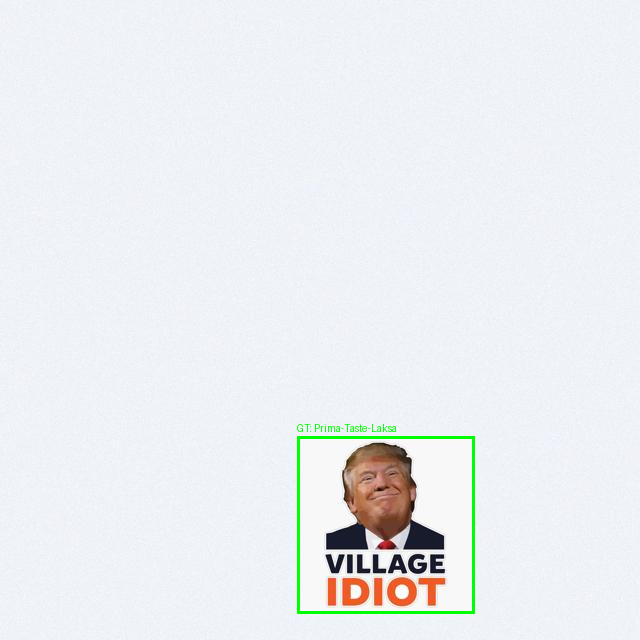

In [7]:
from PIL import ImageDraw
def draw_xywh_boxes(image_path, boxes, color='lime', label_prefix='GT'):
    im = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(im)
    for x, y, w, h, label in boxes:
        draw.rectangle([x, y, x+w, y+h], outline=color, width=3)
        draw.text((x, max(0, y-14)), f'{label_prefix}: {label}', fill=color)
    return im
gt_img = draw_xywh_boxes('datasets/scenes/images/val/scene_000.jpg', scene_map[0][1])
gt_img


## Optional: annotate real scenes

**What:** Use Label Studio or a similar tool if your team wants to replace composed scenes with manually boxed real counter/cart photos.

**Why:** Manual annotation is slower, but it tests whether the detector improves when trained on realistic clutter, lighting, and occlusion.

**Watch for:** Keep the same YOLO format: one `product` box per visible item. Compare manual-data YOLO against the composed-scene baseline.

In [8]:
print('Optional extension, not required for the core lab:')
print('1. Capture real counter/cart photos with multiple grocery items.')
print('2. Annotate visible product boxes in Label Studio as a single class: product.')
print('3. Export YOLO labels and arrange them as images/train, images/val, labels/train, labels/val.')
print('4. Train YOLO on those real annotations and compare mAP + Day 5 demo quality.')


Optional extension, not required for the core lab:
1. Capture real counter/cart photos with multiple grocery items.
2. Annotate visible product boxes in Label Studio as a single class: product.
3. Export YOLO labels and arrange them as images/train, images/val, labels/train, labels/val.
4. Train YOLO on those real annotations and compare mAP + Day 5 demo quality.


## Baseline YOLO11

**What:** Run an out-of-the-box COCO-pretrained YOLO11n on one composed scene.

**Why:** Shows why we must fine-tune: COCO has 'banana' but not 'Granny-Smith' or 'Yoghurt'.

**Watch for:** Detections will be sparse/mislabelled - that's the point, it has never seen our products.

baseline COCO detections: 2 — wrong class space for our products


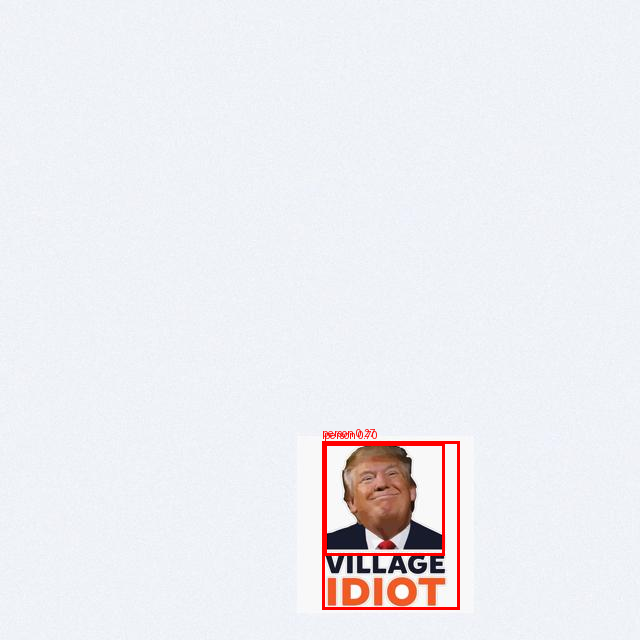

In [9]:
from ultralytics import YOLO
m = YOLO('yolo11n.pt')
r0 = m('datasets/scenes/images/val/scene_000.jpg', verbose=False)[0]
print('baseline COCO detections:', len(r0.boxes), '— wrong class space for our products')
baseline_img = Image.open('datasets/scenes/images/val/scene_000.jpg').convert('RGB')
draw = ImageDraw.Draw(baseline_img)
for box, cls_id, conf in zip(r0.boxes.xyxy.cpu().numpy(), r0.boxes.cls.cpu().numpy(), r0.boxes.conf.cpu().numpy()):
    x1,y1,x2,y2 = [int(v) for v in box]
    label = f'{r0.names.get(int(cls_id), str(int(cls_id)))} {conf:.2f}'
    draw.rectangle([x1,y1,x2,y2], outline='red', width=3)
    draw.text((x1, max(0,y1-14)), label, fill='red')
baseline_img


## Fine-tune YOLO11 (core)

**What:** Train YOLO11 on our class-agnostic product scenes.

**Why:** A few epochs teach it 'this blob is a product' regardless of COCO's vocabulary.

**Watch for:** CPU users get fewer epochs (SC_EPOCHS); Colab GPU gets 20. mAP will be modest on generated data.

In [10]:
epochs = int(os.environ.get('SC_EPOCHS', 20))
res = m.train(data='datasets/scenes/data.yaml', epochs=epochs, imgsz=640, verbose=False)
try:
    print('fine-tuned mAP50-95:', float(res.box.map))
except Exception:
    print('training finished; see runs/ for metrics')
detector_path = os.path.join(getattr(res, 'save_dir', 'runs/detect/train'), 'weights', 'best.pt')
detector = YOLO(detector_path)
print('loaded fine-tuned detector:', detector_path)


Ultralytics 8.4.90 🚀 Python-3.13.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 Super with Max-Q Design, 8192MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/scenes/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=Non

/home/jonyling/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.7it/s 0.4s

                   all         20         67      0.898      0.866      0.947      0.763


Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 2.5ms postprocess per image


Results saved to /home/jonyling/SNAIC/Week4/day_2/runs/detect/train-7


fine-tuned mAP50-95: 0.7634727485240957
loaded fine-tuned detector: /home/jonyling/SNAIC/Week4/day_2/runs/detect/train-7/weights/best.pt


## Baseline vs fine-tuned

**What:** Compare the COCO baseline against the fine-tuned detector on the same scene.

**Why:** Qualitatively the fine-tuned model should box products tightly with the single 'product' class.

**Watch for:** If fine-tuned boxes look worse, you likely need more epochs or more composed scenes.

fine-tuned detections on scene_000: 1
baseline had 2 -> fine-tuned has 1


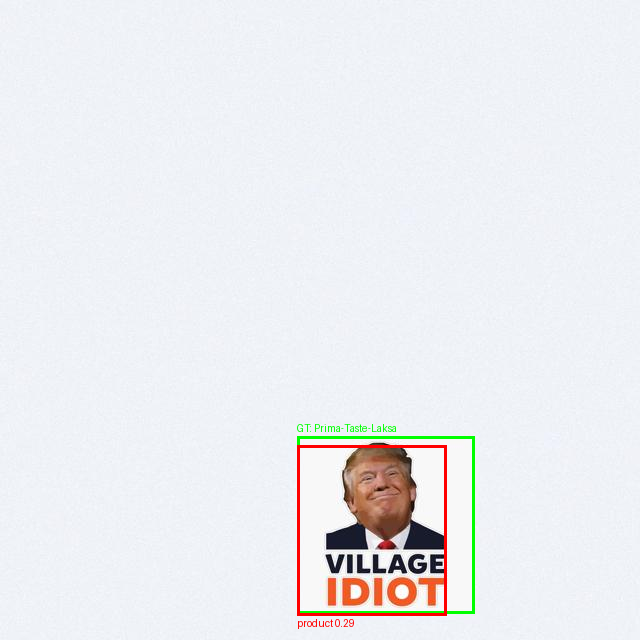

In [11]:
rb = detector('datasets/scenes/images/val/scene_000.jpg', verbose=False)[0]
print('fine-tuned detections on scene_000:', len(rb.boxes))
print('baseline had', len(r0.boxes), '-> fine-tuned has', len(rb.boxes))
compare = draw_xywh_boxes('datasets/scenes/images/val/scene_000.jpg', scene_map[0][1], color='lime', label_prefix='GT')
draw = ImageDraw.Draw(compare)
for box, cls_id, conf in zip(rb.boxes.xyxy.cpu().numpy(), rb.boxes.cls.cpu().numpy(), rb.boxes.conf.cpu().numpy()):
    x1,y1,x2,y2 = [int(v) for v in box]
    label = f'{rb.names.get(int(cls_id), str(int(cls_id)))} {conf:.2f}'
    draw.rectangle([x1,y1,x2,y2], outline='red', width=3)
    draw.text((x1, min(compare.height-16, y2+2)), label, fill='red')
compare


## Explain the detector: YOLO Grad-CAM (ported from Hongming's D5-explainability work)

**What:** A Grad-CAM heatmap over the fine-tuned detector — which pixels drove "a product is here"?

**Why:** This came from a real observed failure: the detector fired on a *background* region. Grad-CAM makes that visible. The detector backbone is a plain CNN, so native Grad-CAM works with no ViT-style caveats. Fully dataset-agnostic (single 'product' class), so it works unchanged on the SG catalog.

**Watch for:** Two non-obvious fixes are load-bearing: Ultralytics caches anchor/stride tensors under `torch.inference_mode()` the first time `detector(...)` runs, which poisons them for autograd — `detect_head.dynamic = True` forces recomputation; and inference models load with `requires_grad=False` everywhere, so the input tensor itself must require grad.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


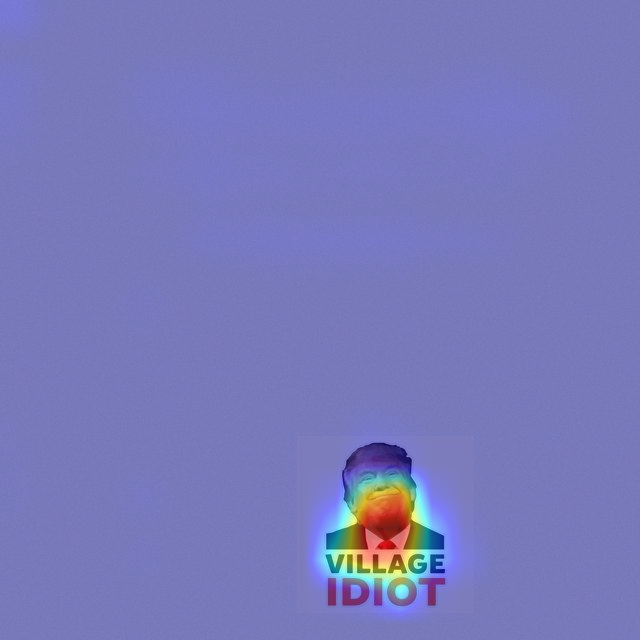

In [12]:
%pip install -q grad-cam

import numpy as np
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class YOLOBoxScoreTarget:
    """Grad-CAM target: the highest class-confidence score anywhere in the raw YOLO
    head output. With a single 'product' class, this is just 'how strongly did the
    detector believe a product exists here' - exactly what we want to explain."""
    def __call__(self, output):
        preds = output[0] if isinstance(output, (list, tuple)) else output
        # Ultralytics raw head output is (batch, 4 + num_classes, num_anchors).
        # Drop the 4 box-coordinate channels, keep only class-confidence channels.
        cls_scores = preds[:, 4:, ...] if preds.dim() == 3 else preds[4:]
        return cls_scores.reshape(-1).max()

def yolo_gradcam(detector, img_path, img_size=640, target_layer=None):
    """Grad-CAM heatmap for a fine-tuned YOLO detector. This is native, unmodified
    Grad-CAM - no ViT-style reshaping or artifact-token caveats needed, because the
    detector backbone is a real CNN."""
    model = detector.model.eval()

    # Ultralytics caches anchor/stride buffers on the Detect head the first time it sees
    # a given input shape. Earlier cells called detector(...) via Ultralytics' predict()
    # path, which runs under torch.inference_mode() - so those cached tensors are
    # permanently off-limits to autograd. Since our Grad-CAM call uses the same 640x640
    # shape, the head would otherwise reuse those poisoned tensors instead of recomputing
    # fresh ones. Forcing dynamic=True makes it always recompute in our own (grad-enabled)
    # forward pass instead.
    detect_head = model.model[-1]
    detect_head.dynamic = True

    if target_layer is None:
        # Last conv-ish block before the detection head.
        # If this looks wrong: print(model.model) and pick a different index.
        target_layer = model.model[-2]

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    rgb = np.asarray(img).astype(np.float32) / 255.0
    input_tensor = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0).float()
    input_tensor.requires_grad_(True)  # needed: Ultralytics loads inference models with
                                        # requires_grad=False on all params, so without this
                                        # nothing in the graph has a grad_fn for CAM to use.

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor, targets=[YOLOBoxScoreTarget()])[0]
    overlay = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)
    return Image.fromarray(overlay), grayscale_cam

overlay_img, heatmap = yolo_gradcam(detector, 'datasets/scenes/images/val/scene_000.jpg')
overlay_img


## Crop ROIs

**What:** Run the fine-tuned detector on every scene, crop each box, and recover its fine label.

**Why:** Day 3 trains a recognizer on real-shaped crops (detector output), not just clean catalog photos.

**Watch for:** Labels are recovered by matching detected boxes to the composed boxes we stashed in scene_map.

In [13]:
import shutil
import pandas as pd
from pathlib import Path
def iou(a, b):
    ax,ay,aw,ah = a; bx,by,bw,bh = b
    ix1,iy1 = max(ax,bx), max(ay,by); ix2,iy2 = min(ax+aw,bx+bw), min(ay+ah,by+bh)
    iw,ih = max(0,ix2-ix1), max(0,iy2-iy1); inter = iw*ih
    union = aw*ah + bw*bh - inter
    return inter/union if union else 0.0
bundle_crops = Path(b.root) / 'crops'
bundle_crops.mkdir(parents=True, exist_ok=True)
rows = []
for i,(split, gboxes) in scene_map.items():
    img = np.array(Image.open(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg').convert('RGB'))
    det = detector(f'datasets/scenes/images/{split}/scene_{i:03d}.jpg', verbose=False)[0]
    for j, box in enumerate(det.boxes.xyxy.cpu().numpy()):
        x1,y1,x2,y2 = [int(v) for v in box]; dw,dh = x2-x1, y2-y1
        if dw < 5 or dh < 5: continue
        best_gt = max(gboxes, key=lambda gb: iou((x1,y1,dw,dh),(gb[0],gb[1],gb[2],gb[3])), default=None)
        if best_gt is None: continue
        fine = best_gt[4]
        cp = bundle_crops / f'scene{i:03d}_{j}.jpg'
        Image.fromarray(img[y1:y2, x1:x2]).save(cp)
        rows.append({'crop_path': str(cp), 'fine': fine})
crops_df = pd.DataFrame(rows)
sample_scene = Path(b.root) / 'sample_scene.jpg'
shutil.copy('datasets/scenes/images/val/scene_000.jpg', sample_scene); b._note('sample_scene.jpg')
# Copy the best fine-tuned weights into the bundle as detector.pt for Day 5.
shutil.copy(detector_path, os.path.join(b.root, 'detector.pt')); b._note('detector.pt')
print('crops:', len(crops_df), '| detector.pt and sample_scene.jpg copied into bundle')


crops: 173 | detector.pt and sample_scene.jpg copied into bundle


## Harden the detector for cluttered baskets

**What:** Retrain YOLO11n on a SECOND composed-scene set that looks like a real shopping
basket: GrabCut product *cutouts* (not square packshots), 3-8 per scene, real occlusion,
random rotation, on store-scene photos and floor/counter/basket-tint canvases. The result
replaces `detector.pt` in the bundle (the original is kept as `detector_v0.pt`).

**Why:** The core fine-tune above pastes whole square studio images onto near-white
canvases with almost no overlap - and scores mAP50-95 0.76 there. On a real 5-product
NTUC basket photo it finds **zero** boxes at serving settings; no inference-time trick
(conf 0.05, imgsz 1280, TTA, even COCO-pretrained YOLO) recovers more than 2/5 items.
Same Day-4 lesson, detection edition: *augmentation must vary what the domain gap varies* -
here that's clutter, occlusion, organic outlines and non-white backgrounds.

**Measured (2026-07-10):** hard-scene val mAP50-95 **0.735**; the 5-product basket photo
goes from 0 boxes to 7 confident regions covering all 5 products; end-to-end top-1 on the
17 real single-product photos **improves** from 11/17 to **13/17** (serve settings,
best-box protocol). A visibility-labeled variant (boxing only un-occluded pixels) scored
better val mAP (0.805) but *over*-segmented real photos (banana bunch -> 12 boxes) and
dropped back to 11/17 - measured and rejected.

**Watch for:** Day 3's crops (above) intentionally still come from the ORIGINAL few-item
detector - the recognition head and its confidence threshold were built on those crops.
Only the bundle's serving weights change here. Re-running this cell retrains (~15 min on
a laptop GPU); the exact weights this recipe produced already ship in `bundle_snapshot/`.


In [ ]:
import sys
import cv2
SG = (HERE.parent / 'sg_data')
if not (USE_SG_CATALOG and SG.exists()):
    print('sg_data not in use - skipping basket-hardening (course-default path).')
else:
    sys.path.insert(0, str(SG))
    from compose_natural_synth import segment_foreground  # proven GrabCut helper (Day 4)
    OUT_HARD = Path('datasets/scenes_hard')
    CANVAS, N_SCENES, CUT_PER_CLASS = 640, 320, 4

    # 1) product cutouts (GrabCut on up to 4 studio shots per class)
    catalog_h = pd.read_csv(SG / 'catalog_prices.csv')
    by_class = {}
    for fine, coarse in zip(catalog_h.fine, catalog_h.coarse):
        kept = 0
        for p in sorted((SG / 'sg_dataset' / 'images' / coarse / fine).glob('*.jpg')):
            if kept >= CUT_PER_CLASS:
                break
            im = cv2.imread(str(p))
            if im is None:
                continue
            h, w = im.shape[:2]
            if max(h, w) > 480:
                s = 480 / max(h, w)
                im = cv2.resize(im, (int(w * s), int(h * s)))
            seg = segment_foreground(im)
            if seg is None:
                continue
            mask, (x0, y0, x1, y1) = seg
            by_class.setdefault(fine, []).append((im[y0:y1, x0:x1], mask[y0:y1, x0:x1]))
            kept += 1
    print('cutouts for', len(by_class), 'classes')

    # 2) background pool: real store scenes + plain floor/counter/basket-tint canvases
    bg_pool = [cv2.imread(str(p)) for p in sorted((SG / 'sg_dataset' / 'natural_scenes').glob('*/*.jpg'))
               if 'Giant_001' not in p.name and cv2.imread(str(p)) is not None]

    def synth_canvas(seed):
        r = np.random.default_rng(seed)
        b_, g_, r_ = [(235, 232, 228), (210, 205, 196), (170, 168, 165),
                      (150, 95, 40), (185, 150, 120), (120, 140, 150)][int(r.integers(0, 6))]
        img = np.zeros((CANVAS, CANVAS, 3), np.uint8)
        img[..., 0], img[..., 1], img[..., 2] = b_, g_, r_
        img = np.clip(img.astype(np.int16) + r.integers(-10, 10, img.shape), 0, 255).astype(np.uint8)
        if r.random() < 0.6:  # faint tile/basket grid
            step, shade = int(r.integers(60, 160)), int(r.integers(-40, -15))
            for x in range(0, CANVAS, step):
                img[:, x:x + 3] = np.clip(img[:, x:x + 3].astype(np.int16) + shade, 0, 255).astype(np.uint8)
            for y in range(0, CANVAS, step):
                img[y:y + 3, :] = np.clip(img[y:y + 3, :].astype(np.int16) + shade, 0, 255).astype(np.uint8)
        return img

    def random_bg(i):
        r = np.random.default_rng(1000 + i)
        if bg_pool and r.random() < 0.45:
            im = bg_pool[int(r.integers(0, len(bg_pool)))]
            h, w = im.shape[:2]
            side = int(min(h, w) * r.uniform(0.6, 1.0))
            y, x = int(r.integers(0, h - side + 1)), int(r.integers(0, w - side + 1))
            return cv2.resize(im[y:y + side, x:x + side], (CANVAS, CANVAS))
        return synth_canvas(2000 + i)

    def iou_xyxy(a, b):
        ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
        ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
        inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
        u = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
        return inter / u if u else 0.0

    def paste_hard(canvas, crop, mask, scale, r):
        th = max(24, int(CANVAS * scale))
        aspect = crop.shape[1] / crop.shape[0]
        tw = max(24, int(th * aspect))
        if tw > int(CANVAS * 0.85):
            tw = int(CANVAS * 0.85); th = max(24, int(tw / aspect))
        c = cv2.resize(crop, (tw, th)); m = cv2.resize(mask, (tw, th))
        deg = float(r.uniform(-25, 25))
        diag = int(np.ceil(np.hypot(tw, th)))
        c = cv2.copyMakeBorder(c, (diag - th) // 2, (diag - th) // 2, (diag - tw) // 2,
                               (diag - tw) // 2, cv2.BORDER_REPLICATE)
        m = cv2.copyMakeBorder(m, (diag - th) // 2, (diag - th) // 2, (diag - tw) // 2,
                               (diag - tw) // 2, cv2.BORDER_CONSTANT, value=0)
        M = cv2.getRotationMatrix2D((c.shape[1] / 2, c.shape[0] / 2), deg, 1.0)
        c = cv2.warpAffine(c, M, (c.shape[1], c.shape[0]), borderMode=cv2.BORDER_REPLICATE)
        m = cv2.warpAffine(m, M, (m.shape[1], m.shape[0]), borderMode=cv2.BORDER_CONSTANT)
        ys, xs = np.where(m > 0)
        if len(ys) == 0:
            return None
        c = c[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
        m = m[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
        ph, pw = c.shape[:2]
        if ph >= CANVAS or pw >= CANVAS:
            return None
        x0 = int(r.integers(0, CANVAS - pw)); y0 = int(r.integers(0, CANVAS - ph))
        sh = np.zeros((CANVAS, CANVAS), np.float32)  # drop shadow
        cv2.ellipse(sh, (x0 + pw // 2, min(CANVAS - 1, y0 + ph - int(0.05 * ph))),
                    (int(pw * 0.42), max(3, int(ph * 0.06))), 0, 0, 360, 0.3, -1)
        sh = cv2.GaussianBlur(sh, (25, 25), 0)[..., None]
        canvas[:] = (canvas.astype(np.float32) * (1 - sh)).astype(np.uint8)
        roi = canvas[y0:y0 + ph, x0:x0 + pw].astype(np.float32)  # brightness nudge + feathered blend
        bg_l = float(cv2.cvtColor(roi.astype(np.uint8), cv2.COLOR_BGR2GRAY).mean())
        fg_l = float(cv2.cvtColor(c, cv2.COLOR_BGR2GRAY).mean()) + 1e-6
        gain = float(np.clip(1.0 + (bg_l / fg_l - 1.0) * 0.35, 0.5, 1.3))
        alpha = (cv2.GaussianBlur(m, (7, 7), 0).astype(np.float32) / 255)[..., None]
        canvas[y0:y0 + ph, x0:x0 + pw] = (alpha * np.clip(c.astype(np.float32) * gain, 0, 255)
                                          + (1 - alpha) * roi).astype(np.uint8)
        return (x0, y0, x0 + pw, y0 + ph)

    # 3) compose 320 cluttered scenes (20% stay 1-2 items so single uploads keep working)
    for split in ('train', 'val'):
        (OUT_HARD / 'images' / split).mkdir(parents=True, exist_ok=True)
        (OUT_HARD / 'labels' / split).mkdir(parents=True, exist_ok=True)
    fines = sorted(by_class)
    for i in range(N_SCENES):
        r = np.random.default_rng(3000 + i)
        split = 'val' if i % 4 == 0 else 'train'
        canvas = random_bg(i).copy()
        n_items = int(r.integers(1, 3)) if r.random() < 0.2 else int(r.integers(3, 9))
        picks = []
        for fine in r.choice(fines, size=n_items, replace=True):
            c, m = by_class[fine][int(r.integers(0, len(by_class[fine])))]
            picks.append((float(r.uniform(0.18, 0.50)), c, m))
        picks.sort(key=lambda t: -t[0])          # big first, small on top
        boxes = []
        for scale, c, m in picks:
            placed = None
            for _ in range(30):
                trial = canvas.copy()
                bb = paste_hard(trial, c, m, scale, r)
                if bb is None:
                    break
                if all(iou_xyxy(bb, b_) < 0.45 for b_ in boxes):
                    canvas, placed = trial, bb
                    break
            else:                                 # crowded: accept last try (real occlusion)
                if bb is not None:
                    canvas, placed = trial, bb
            if placed:
                boxes.append(placed)
        if not boxes:
            continue
        cv2.imwrite(str(OUT_HARD / 'images' / split / f'hard_{i:03d}.jpg'), canvas,
                    [cv2.IMWRITE_JPEG_QUALITY, 92])
        (OUT_HARD / 'labels' / split / f'hard_{i:03d}.txt').write_text('\n'.join(
            f'0 {(x1 + x2) / 2 / CANVAS:.6f} {(y1 + y2) / 2 / CANVAS:.6f} '
            f'{(x2 - x1) / CANVAS:.6f} {(y2 - y1) / CANVAS:.6f}' for x1, y1, x2, y2 in boxes))
    (OUT_HARD / 'data.yaml').write_text(
        f'path: {OUT_HARD.resolve()}\ntrain: images/train\nval: images/val\nnames:\n  0: product\n')
    n_tr = len(list((OUT_HARD / 'images' / 'train').glob('*.jpg')))
    print(f'composed {n_tr} hard train scenes')

    # 4) retrain from the COCO checkpoint (NOT from the packshot model - avoid its bias)
    hard_epochs = int(os.environ.get('SC_HARDEN_EPOCHS', 40))
    mh = YOLO('yolo11n.pt')
    res_h = mh.train(data=str(OUT_HARD / 'data.yaml'), epochs=hard_epochs, imgsz=640,
                     seed=0, degrees=15.0, verbose=False)
    print('hard-scene mAP50-95:', float(res_h.box.map))
    hard_path = os.path.join(getattr(res_h, 'save_dir', 'runs/detect/train'), 'weights', 'best.pt')

    # 5) ship: hardened weights become the SERVING detector; original kept as v0
    import shutil as _sh
    v0 = Path(b.root) / 'detector_v0.pt'
    if not v0.exists():
        _sh.copy(os.path.join(b.root, 'detector.pt'), v0)
    _sh.copy(hard_path, os.path.join(b.root, 'detector.pt'))
    b._note('detector.pt'); b._note('detector_v0.pt')
    b.manifest['detector_note'] = ('detector.pt retrained on cluttered basket-style composites '
                                   '(GrabCut cutouts, 3-8 items/scene, occlusion); '
                                   'detector_v0.pt is the original sparse-scene model')
    # quick sanity on the real 5-product basket photo, if present
    basket = SG / 'sg_dataset' / 'natural_multi' / 'Basket_001.jpg'
    if basket.exists():
        arr_b = np.array(Image.open(basket).convert('RGB'))
        n_old = len(YOLO(str(v0))(arr_b, imgsz=640, conf=0.25, verbose=False)[0].boxes)
        n_new = len(YOLO(hard_path)(arr_b, imgsz=640, conf=0.25, verbose=False)[0].boxes)
        print(f'basket photo boxes at serve settings: old={n_old}  hardened={n_new}')
    print('hardened detector shipped to bundle as detector.pt')


## Save + carry forward

**What:** Persist the crops manifest and save the bundle.

**Why:** Day 3 reads `crops_manifest.csv`; Day 5 uses `sample_scene.jpg` for a fresh-runtime demo.

**Watch for:** Confirm detector.pt and sample_scene.jpg show up in the bundle artifacts.

In [14]:
b.put_table('crops_manifest.csv', crops_df)
save_bundle(b)
print('\u25b6 Carries forward to Day 3/5: detector.pt + crops_manifest.csv + sample_scene.jpg')


[bundle] saved -> /home/jonyling/SmartCart_bundle
▶ Carries forward to Day 3/5: detector.pt + crops_manifest.csv + sample_scene.jpg
